# Donghang Zou's UChicago ADS Code Sample

In [1]:
# GitHub: https://github.com/Booth-DH/Global_AI_Internship

### 1. Motivation and data

This sample is an excerpt from my Global AI internship project; the full code and analysis are available at the GitHub link above. Chronic disease burden varies across U.S. counties, and its social correlates can guide public health resources. The project joins CDC PLACES 2021 to 2025 with CDC SVI 2020 and 2022 in a county panel, compares diabetes and hypertension correlates, and maps K-means profiles. Food, housing, and transportation insecurity are the strongest diabetes correlates (r of 0.937, 0.921, and 0.914). The code below uses the latest snapshot.

### 2. Setup and loading the data

In [2]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import patches, path
from sklearn import cluster, preprocessing, metrics

ROOT = Path.cwd().parent if Path.cwd().name == 'code_sample' else Path.cwd()
RAW, OUT = ROOT / 'data/raw', ROOT / 'code_sample'
outcomes = ['DIABETES', 'BPHIGH']
factor_labels = {'LPA': 'Inactivity', 'OBESITY': 'Obesity', 'CSMOKING': 'Smoking', 'ACCESS2': 'Uninsured',
    'DEPRESSION': 'Depression', 'SLEEP': 'Short sleep', 'BINGE': 'Binge drinking', 'RPL_THEMES': 'Overall SVI',
    'RPL_THEME1': 'SVI: socioeconomic', 'RPL_THEME2': 'SVI: household', 'RPL_THEME3': 'SVI: minority',
    'RPL_THEME4': 'SVI: housing/transport', 'FOODINSECU': 'Food insecurity', 'HOUSINSECU': 'Housing insecurity',
    'LACKTRPT': 'Transport barriers', 'LONELINESS': 'Loneliness'}
factors = list(factor_labels)
svi_cols = [factor for factor in factors if factor.startswith('RPL')]
# String identifiers preserve leading zeros.
places = pd.read_csv(RAW / 'places_county_2025.csv', low_memory=False,
    dtype={'locationid': 'string', 'year': 'int16', 'data_value': 'float64'})
svi = pd.read_csv(RAW / 'svi_county_2022.csv', dtype={'FIPS': 'string'}, usecols=['FIPS', *svi_cols])
print(f'locationid: {places.locationid.dtype}; FIPS: {svi.FIPS.dtype}; data_value: {places.data_value.dtype}')

Matplotlib is building the font cache; this may take a moment.


locationid: string; FIPS: string; data_value: float64


### 3. Building the county snapshot



In [3]:
def prepare_county_snapshot(places, svi):
    health = places.loc[places.stateabbr.ne('US') & places.data_value_type.eq('Age-adjusted prevalence')].copy()
    health['FIPS'] = health.locationid.str.zfill(5)
    health = health.sort_values('year').drop_duplicates(['FIPS', 'measureid'], keep='last')
    wide = health.pivot(index='FIPS', columns='measureid', values='data_value')
    # Treat -999 as missing.
    svi = svi.assign(FIPS=svi.FIPS.str.zfill(5)).replace(-999, np.nan).set_index('FIPS')
    # Validation raises an error for duplicate county identifiers.
    return wide.join(svi, validate='one_to_one').dropna(subset=[*outcomes, 'RPL_THEMES'])
counties = prepare_county_snapshot(places, svi)

### 4. Measuring associations

Pearson r measures association; pairwise uses available counties, while common holds the sample fixed.

In [4]:
def compare_correlations(data, outcome, factors, sample_policy='pairwise'):
    rows = data[[outcome, *factors]].dropna(subset=[outcome, *factors] if sample_policy == 'common' else [outcome])
    return pd.DataFrame({'r': rows[factors].corrwith(rows[outcome]), 'n': rows[factors].count()})
results = {outcome: compare_correlations(counties, outcome, factors) for outcome in outcomes}
correlations = pd.DataFrame({outcome: result.r for outcome, result in results.items()})
shown = ['FOODINSECU', 'HOUSINSECU', 'LACKTRPT', 'LPA']
common = compare_correlations(counties, 'DIABETES', factors, 'common')
comparison = results['DIABETES'].join(common, lsuffix='_pair', rsuffix='_common').loc[shown]
comparison.to_csv(OUT / 'tables/correlation_summary.csv')
print(comparison.round(3).rename_axis(None))

            r_pair  n_pair  r_common  n_common
FOODINSECU   0.937    2299     0.937      2299
HOUSINSECU   0.921    2299     0.921      2299
LACKTRPT     0.914    2299     0.914      2299
LPA          0.873    2956     0.850      2299


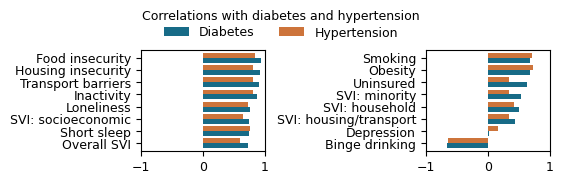

In [5]:
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 9, 'figure.titlesize': 9})
def plot_correlations(correlations):
    ranked = correlations.sort_values('DIABETES', ascending=False).rename(index=factor_labels)
    fig, axes = plt.subplots(1, 2, figsize=(5.6, 1.75))
    for ax, start in zip(axes, [0, 8]):
        ranked.iloc[start:start + 8].iloc[::-1].plot.barh(ax=ax, width=.8,
            color=['#176b87', '#cd743b'], legend=False)
        ax.set(xlim=(-1, 1), xticks=[-1, 0, 1], xlabel='', ylabel='')
    fig.suptitle('Correlations with diabetes and hypertension')
    fig.legend(['Diabetes', 'Hypertension'], loc='upper center', bbox_to_anchor=(.5, .95), ncol=2, frameon=False)
    fig.subplots_adjust(left=.25, right=.98, bottom=.17, top=.75, wspace=1.3)
    return fig
figure = plot_correlations(correlations); figure.savefig(OUT / 'figures/fig_correlations.png', dpi=240); plt.show()

### 5. Grouping and mapping counties

Clustering groups counties by standardized disease and vulnerability profiles so units do not determine distance.

In [6]:
strength = correlations.abs().mean(axis=1).sort_values(ascending=False)
features = outcomes + strength[strength >= .40].index.tolist()
complete = counties.dropna(subset=features).copy()
scaled = preprocessing.StandardScaler().fit_transform(complete[features])
model = cluster.KMeans(n_clusters=4, random_state=42, n_init=10).fit(scaled)
anchors = [features.index(factor) for factor in [*outcomes, 'RPL_THEMES']]
# Order tiers by mean standardized diabetes, hypertension, and SVI.
order = np.argsort(model.cluster_centers_[:, anchors].mean(axis=1))
tiers = ['Low', 'Moderate', 'High', 'Highest']
labels = pd.Series(model.labels_, index=complete.index).map(dict(zip(order, tiers)))
complete['tier'] = pd.Categorical(labels, categories=tiers, ordered=True)
summary = complete.groupby('tier', observed=True).agg(counties=('DIABETES', 'size'),
    diabetes=('DIABETES', 'mean'), hypertension=('BPHIGH', 'mean'), SVI=('RPL_THEMES', 'mean'))
print(f'{len(complete):,} clustered counties; silhouette = {metrics.silhouette_score(scaled, model.labels_):.3f}')
print(summary.round(3).rename_axis(None).to_string())

2,299 clustered counties; silhouette = 0.203
          counties  diabetes  hypertension    SVI
Low            765     9.090        29.758  0.190
Moderate       788    10.765        33.306  0.456
High           508    12.555        36.755  0.754
Highest        238    15.786        42.943  0.895


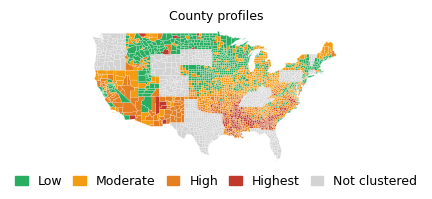

In [7]:
def plot_county_profiles(complete):
    colors = dict(zip([*tiers, 'Not clustered'], ['#27ae60', '#f39c12', '#e67e22', '#c0392b', '#d3d3d3']))
    lookup = complete.tier.astype('string').map(colors).to_dict()
    geo = json.loads((ROOT / 'data/processed/us_counties.geojson').read_text())
    fig, ax = plt.subplots(figsize=(5.6, 1.9)); ax.axis('off')
    visible = [county for county in geo['features'] if county['id'][:2] not in {'02', '15', '72'}]
    for county in visible:
        fips, geometry = county['id'], county['geometry']
        polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
        for polygon in polygons:
            shape = path.Path.make_compound_path(*[path.Path(ring, closed=True) for ring in polygon])
            ax.add_patch(patches.PathPatch(shape, facecolor=lookup.get(fips, '#d3d3d3'), edgecolor='w', lw=.12))
    ax.set(xlim=(-125, -66), ylim=(24, 50), aspect=1.25, title='County profiles')
    handles = [patches.Patch(color=color, label=tier) for tier, color in colors.items()]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, columnspacing=.9, handlelength=1)
    fig.subplots_adjust(left=.02, right=.98, top=.88, bottom=.16)
    return fig
figure = plot_county_profiles(complete); figure.savefig(OUT / 'figures/fig_risk_tier_map.png', dpi=240); plt.show()

Grey marks nine states missing social-needs measures (CO, FL, OR, SD, TN, TX, VT, WA, WY) and KY/PA missing diabetes and hypertension. Nine CT planning regions lack cached geometry.

### 6. Findings and limits

Social-needs factors remain the strongest diabetes correlates across the same 2,299 counties; inactivity weakens. Higher-burden profiles cluster in the Deep South. These associations could prioritize county follow-up, but are descriptive, not causal: measurement years differ and profiles overlap.